# Train Frame Order Prediction for Temporal Learning

This notebook trains a model to predict the original position of frames in a shuffled video sequence.

**Goal**: Learn temporal representations by understanding frame ordering in threshold sequences (before → threshold → after).

## Setup

In [1]:
import sys
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from config_temporal import get_temporal_config
from frame_order_model import create_frame_order_model
from dataset_temporal import create_temporal_dataloaders

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f"Device: {device}")

PyTorch version: 2.10.0.dev20251029+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
Device: cuda


## Configuration

In [2]:
# Data path
DATA_ROOT = r"C:\Users\shrua\OneDrive\Desktop\threshold project\threshold\data"

# Training hyperparameters
NUM_EPOCHS = 30
BATCH_SIZE = 64
NUM_WORKERS = 4
TRAIN_SPLIT = 0.85

# Resume training
RESUME_FROM = None  # Set to checkpoint path to resume

# Output
OUTPUT_DIR = '../models_temporal/output_temporal'
CHECKPOINT_DIR = os.path.join(OUTPUT_DIR, 'checkpoints')
VIS_DIR = os.path.join(OUTPUT_DIR, 'visualizations')
SAVE_EVERY = 5

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(VIS_DIR, exist_ok=True)

print(f"Configuration:")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Output: {OUTPUT_DIR}")

Configuration:
  Epochs: 30
  Batch size: 64
  Output: ../models_temporal/output_temporal


## Create Model

In [3]:
# Get config
config = get_temporal_config()

# Create frame order model
model = create_frame_order_model(config)
model = model.to(device)

print(f"\nModel parameters:")
total_params = sum(p.numel() for p in model.parameters())
encoder_params = sum(p.numel() for p in model.encoder.parameters())
head_params = sum(p.numel() for p in model.position_head.parameters())
print(f"  Total: {total_params:,}")
print(f"  Encoder: {encoder_params:,}")
print(f"  Position head: {head_params:,}")


Model parameters:
  Total: 21,434,631
  Encoder: 21,334,272
  Position head: 100,359


## Create Data Loaders

In [4]:
train_loader, val_loader, full_dataset, train_indices, val_indices = create_temporal_dataloaders(
    data_root=DATA_ROOT,
    batch_size=BATCH_SIZE,
    train_split=TRAIN_SPLIT,
    num_workers=NUM_WORKERS,
)

print(f"Data loaded:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")

Found 8 threshold CSV files
Loaded 1799 threshold sequences from 8 files
Loaded 1799 threshold sequences from 8 files

TYPOLOGY DISTRIBUTION (before splitting)
  t1: 207 samples (11.5%)
  t2: 244 samples (13.6%)
  t3: 211 samples (11.7%)
  t4: 200 samples (11.1%)
  t5: 222 samples (12.3%)
  t6: 210 samples (11.7%)
  t7: 286 samples (15.9%)
  t8: 219 samples (12.2%)

Stratified split completed:
  Train samples: 1526
  Val samples: 273

TRAIN SET DISTRIBUTION:
  t1: 175 samples (11.5%)
  t2: 207 samples (13.6%)
  t3: 179 samples (11.7%)
  t4: 170 samples (11.1%)
  t5: 188 samples (12.3%)
  t6: 178 samples (11.7%)
  t7: 243 samples (15.9%)
  t8: 186 samples (12.2%)

VAL SET DISTRIBUTION:
  t1: 32 samples (11.7%)
  t2: 37 samples (13.6%)
  t3: 32 samples (11.7%)
  t4: 30 samples (11.0%)
  t5: 34 samples (12.5%)
  t6: 32 samples (11.7%)
  t7: 43 samples (15.8%)
  t8: 33 samples (12.1%)

Data loaded:
  Train batches: 23
  Val batches: 5


## Setup Optimizer

In [5]:
# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config.learning_rate,
    weight_decay=config.weight_decay,
    betas=(0.9, 0.95)
)

# Learning rate scheduler with warmup
def lr_lambda(epoch):
    if epoch < config.warmup_epochs:
        return (epoch + 1) / config.warmup_epochs
    else:
        # Cosine decay after warmup
        progress = (epoch - config.warmup_epochs) / (config.max_epochs - config.warmup_epochs)
        return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Training state
start_epoch = 0
train_losses = []
val_losses = []
train_accs = []
val_accs = []
best_val_loss = float('inf')

if RESUME_FROM is not None:
    print(f"Loading checkpoint from: {RESUME_FROM}")
    checkpoint = torch.load(RESUME_FROM, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    if 'train_losses' in checkpoint:
        train_losses = checkpoint['train_losses']
    if 'val_losses' in checkpoint:
        val_losses = checkpoint['val_losses']
    if 'train_accs' in checkpoint:
        train_accs = checkpoint['train_accs']
    if 'val_accs' in checkpoint:
        val_accs = checkpoint['val_accs']
    if 'best_val_loss' in checkpoint:
        best_val_loss = checkpoint['best_val_loss']
    for _ in range(start_epoch):
        scheduler.step()
    print(f"Resuming from epoch {start_epoch}")
else:
    print("Starting fresh training")

print(f"Optimizer: AdamW (lr={config.learning_rate}, wd={config.weight_decay})")
print(f"Scheduler: Warmup {config.warmup_epochs} epochs + Cosine decay")

Starting fresh training
Optimizer: AdamW (lr=0.0003, wd=0.0005)
Scheduler: Warmup 10 epochs + Cosine decay


## Training Loop

In [6]:
print("="*80)
print("TRAINING")
print("="*80)
print()

for epoch in range(start_epoch, NUM_EPOCHS):
    # ============ Training ============
    model.train()
    train_loss_epoch = 0.0
    train_correct = 0
    train_total = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]")
    for batch in pbar:
        frames = batch['frames'].to(device)  # [B, 7, 1, 32, 64]
        targets = batch['targets'].to(device)  # [B, 7]
        
        # Forward pass
        loss, logits = model(frames, targets)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss_epoch += loss.item()
        
        # Calculate accuracy
        preds = logits.argmax(dim=-1)  # (B, 7)
        train_correct += (preds == targets).sum().item()
        train_total += targets.numel()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{train_correct/train_total:.3f}'})
    
    train_loss_epoch /= len(train_loader)
    train_acc_epoch = train_correct / train_total
    train_losses.append(train_loss_epoch)
    train_accs.append(train_acc_epoch)
    
    # ============ Validation ============
    model.eval()
    val_loss_epoch = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]")
        for batch in pbar:
            frames = batch['frames'].to(device)
            targets = batch['targets'].to(device)
            
            loss, logits = model(frames, targets)
            val_loss_epoch += loss.item()
            
            # Calculate accuracy
            preds = logits.argmax(dim=-1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.numel()
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{val_correct/val_total:.3f}'})
    
    val_loss_epoch /= len(val_loader)
    val_acc_epoch = val_correct / val_total
    val_losses.append(val_loss_epoch)
    val_accs.append(val_acc_epoch)
    
    # Update learning rate
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    # Print epoch summary
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}:")
    print(f"  Train Loss: {train_loss_epoch:.4f}  |  Train Acc: {train_acc_epoch:.3f}")
    print(f"  Val Loss:   {val_loss_epoch:.4f}  |  Val Acc:   {val_acc_epoch:.3f}")
    print(f"  LR:         {current_lr:.2e}")
    
    # Save best model
    if val_loss_epoch < best_val_loss:
        best_val_loss = val_loss_epoch
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': train_loss_epoch,
            'val_loss': val_loss_epoch,
            'train_acc': train_acc_epoch,
            'val_acc': val_acc_epoch,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_accs': train_accs,
            'val_accs': val_accs,
            'best_val_loss': best_val_loss,
            'config': config,
        }, os.path.join(CHECKPOINT_DIR, 'best_model.pt'))
        print(f"  → Best model saved! (val_loss: {val_loss_epoch:.4f})")
    
    # Save periodic checkpoint
    if (epoch + 1) % SAVE_EVERY == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': train_loss_epoch,
            'val_loss': val_loss_epoch,
            'train_acc': train_acc_epoch,
            'val_acc': val_acc_epoch,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_accs': train_accs,
            'val_accs': val_accs,
            'best_val_loss': best_val_loss,
            'config': config,
        }, os.path.join(CHECKPOINT_DIR, f'checkpoint_epoch_{epoch+1}.pt'))
        print(f"  → Checkpoint saved (epoch {epoch+1})")
    
    print()

print("="*80)
print("TRAINING COMPLETE!")
print("="*80)
print(f"Best validation loss: {best_val_loss:.4f}")

# Save final model
torch.save({
    'epoch': NUM_EPOCHS - 1,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_accs': train_accs,
    'val_accs': val_accs,
    'best_val_loss': best_val_loss,
    'config': config,
}, os.path.join(CHECKPOINT_DIR, 'final_model.pt'))

# Save encoder only
encoder_state = {}
for k, v in model.state_dict().items():
    if k.startswith('encoder'):
        encoder_state[k] = v
torch.save(encoder_state, os.path.join(OUTPUT_DIR, 'encoder_temporal_pretrained.pt'))
print(f"Encoder saved to: {os.path.join(OUTPUT_DIR, 'encoder_temporal_pretrained.pt')}")

TRAINING



Epoch 1/30 [Train]:   0%|          | 0/23 [00:07<?, ?it/s]

Epoch 1/30 [Val]:   0%|          | 0/5 [00:06<?, ?it/s]

Epoch 1/30:
  Train Loss: 1.7444  |  Train Acc: 0.260
  Val Loss:   1.5590  |  Val Acc:   0.330
  LR:         6.00e-05
  → Best model saved! (val_loss: 1.5590)



Epoch 2/30 [Train]:   0%|          | 0/23 [00:06<?, ?it/s]

...

Epoch 23/30 [Train]:   0%|          | 0/23 [00:06<?, ?it/s]

Epoch 23/30 [Val]:   0%|          | 0/5 [00:06<?, ?it/s]

Epoch 23/30:
  Train Loss: 0.0002  |  Train Acc: 1.000
  Val Loss:   0.0085  |  Val Acc:   0.997
  LR:         2.97e-04



Epoch 24/30 [Train]:   0%|          | 0/23 [00:06<?, ?it/s]

KeyboardInterrupt: 

## Visualize Training Curves

ValueError: x and y must have same first dimension, but have shapes (24,) and (23,)

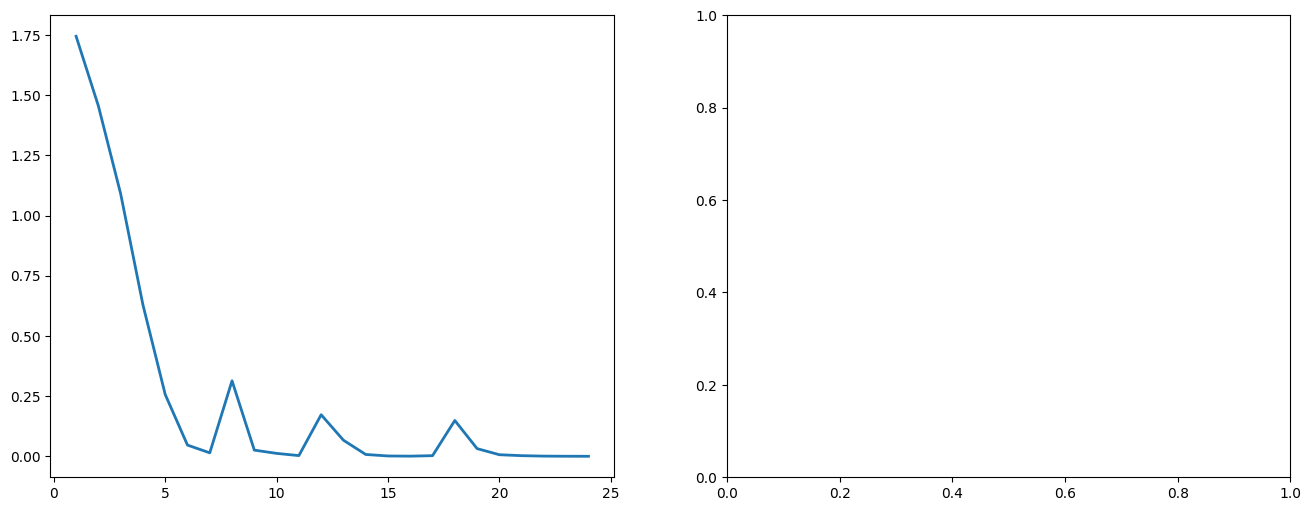

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

epochs = np.arange(1, len(train_losses) + 1)

# Loss plot
ax = axes[0]
ax.plot(epochs, train_losses, label='Train Loss', linewidth=2)
ax.plot(epochs, val_losses, label='Val Loss', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax.set_title('Training Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Accuracy plot
ax = axes[1]
ax.plot(epochs, train_accs, label='Train Accuracy', linewidth=2)
ax.plot(epochs, val_accs, label='Val Accuracy', linewidth=2)
ax.axhline(y=1/7, color='red', linestyle='--', label='Random (14.3%)', alpha=0.5)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Position Prediction Accuracy', fontsize=12)
ax.set_title('Training Accuracy', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
plt.show()

print(f"Training curves saved to: {os.path.join(OUTPUT_DIR, 'training_curves.png')}")

## Evaluate t-SNE Clustering

Evaluate how well the temporal encoder learned typology-distinguishing features by extracting sequence-level embeddings and visualizing with t-SNE.

In [8]:
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.cluster import KMeans

print("="*80)
print("EXTRACTING MAE EMBEDDINGS")
print("="*80)
print()

# Load best model
checkpoint = torch.load(os.path.join(CHECKPOINT_DIR, 'best_model.pt'), weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print("Loaded best model (epoch {}, val_loss: {:.4f}, val_acc: {:.3f})".format(
    checkpoint['epoch'], checkpoint['val_loss'], checkpoint['val_acc']))
print()

# Extract embeddings from validation set (original order, no shuffling)
embeddings = []
labels = []
typology_names_list = []

print("Extracting embeddings from validation set...")
with torch.no_grad():
    for idx in tqdm(val_indices):
        sample = full_dataset[idx]
        frames = sample['frames'].unsqueeze(0).to(device)  # (1, 7, 1, 32, 64)
        
        # Extract frame embeddings
        h_frames = model.get_frame_embeddings(frames)  # (1, 7, 384)
        
        # Average pool across all frames to get sequence-level embedding
        h_seq = h_frames.mean(dim=1)  # (1, 384)
        
        embeddings.append(h_seq.cpu().numpy())
        labels.append(sample['typology_label'])
        typology_names_list.append(sample['metadata']['typology'].split('-')[0])

embeddings = np.concatenate(embeddings, axis=0)  # (N, 384)
labels = np.array(labels)  # (N,)

print(f"\nExtracted {len(embeddings)} embeddings")
print(f"Embedding shape: {embeddings.shape}")
print()

# Analyze typology distribution
print("="*80)
print("TYPOLOGY DISTRIBUTION IN VALIDATION SET")
print("="*80)
unique_labels = np.unique(labels)
unique_typologies = sorted(set(typology_names_list))
print(f"Number of unique typologies: {len(unique_labels)}")
print(f"Unique typology names: {unique_typologies}")
print()

print("Sample counts per typology:")
for typology in unique_typologies:
    count = sum(1 for t in typology_names_list if t == typology)
    sample_idx = typology_names_list.index(typology)
    label_idx = labels[sample_idx]
    print(f"  {typology} (label {label_idx}): {count} samples")
print()

if len(unique_labels) < 8:
    print(f"⚠ WARNING: Only {len(unique_labels)} typologies in validation set!")
else:
    print("✓ All 8 typologies present in validation set")
print()
print("="*80)

EXTRACTING MAE EMBEDDINGS

Loaded best model (epoch 21, val_loss: 0.0026, val_acc: 0.999)

Extracting embeddings from validation set...


  0%|          | 0/273 [00:00<?, ?it/s]


Extracted 273 embeddings
Embedding shape: (273, 384)

TYPOLOGY DISTRIBUTION IN VALIDATION SET
Number of unique typologies: 8
Unique typology names: ['t1', 't2', 't3', 't4', 't5', 't6', 't7', 't8']

Sample counts per typology:
  t1 (label 0): 32 samples
  t2 (label 1): 37 samples
  t3 (label 2): 32 samples
  t4 (label 3): 30 samples
  t5 (label 4): 34 samples
  t6 (label 5): 32 samples
  t7 (label 6): 43 samples
  t8 (label 7): 33 samples

✓ All 8 typologies present in validation set



In [9]:
# Compute t-SNE
print("Computing t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings) // 4))
embeddings_2d = tsne.fit_transform(embeddings)
print("t-SNE complete")
print()

# Compute clustering metrics
num_clusters = len(unique_labels)
silhouette = silhouette_score(embeddings, labels)

# K-means clustering
print(f"Running K-means with {num_clusters} clusters...")
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
pred_labels = kmeans.fit_predict(embeddings)
ari = adjusted_rand_score(labels, pred_labels)

print("="*80)
print("CLUSTERING METRICS")
print("="*80)
print(f"Number of typologies: {num_clusters}")
print(f"Silhouette Score: {silhouette:.3f} (range: -1 to 1, higher is better)")
print(f"Adjusted Rand Index (ARI): {ari:.3f} (range: 0 to 1, higher is better)")
print()

# Interpret results
print("Silhouette Score interpretation:")
if silhouette > 0.3:
    print("  ✓ EXCELLENT! Silhouette > 0.3 indicates good clustering!")
elif silhouette > 0.1:
    print("  ✓ GOOD! Silhouette > 0.1 shows some clustering structure.")
elif silhouette > 0:
    print("  ~ MARGINAL. Silhouette > 0 but weak clustering.")
else:
    print("  ✗ POOR. Negative silhouette indicates random/overlapping clusters.")
print()

print("ARI interpretation:")
if ari > 0.5:
    print("  ✓ EXCELLENT! ARI > 0.5 indicates strong agreement with typologies!")
elif ari > 0.3:
    print("  ✓ GOOD! ARI > 0.3 shows reasonable clustering.")
elif ari > 0.1:
    print("  ~ MARGINAL. ARI > 0.1 but weak agreement.")
else:
    print("  ✗ POOR. ARI near 0 indicates no clustering structure.")

print("="*80)

Computing t-SNE (this may take a minute)...
t-SNE complete

Running K-means with 8 clusters...
CLUSTERING METRICS
Number of typologies: 8
Silhouette Score: 0.096 (range: -1 to 1, higher is better)
Adjusted Rand Index (ARI): 0.469 (range: 0 to 1, higher is better)

Silhouette Score interpretation:
  ~ MARGINAL. Silhouette > 0 but weak clustering.

ARI interpretation:
  ✓ GOOD! ARI > 0.3 shows reasonable clustering.


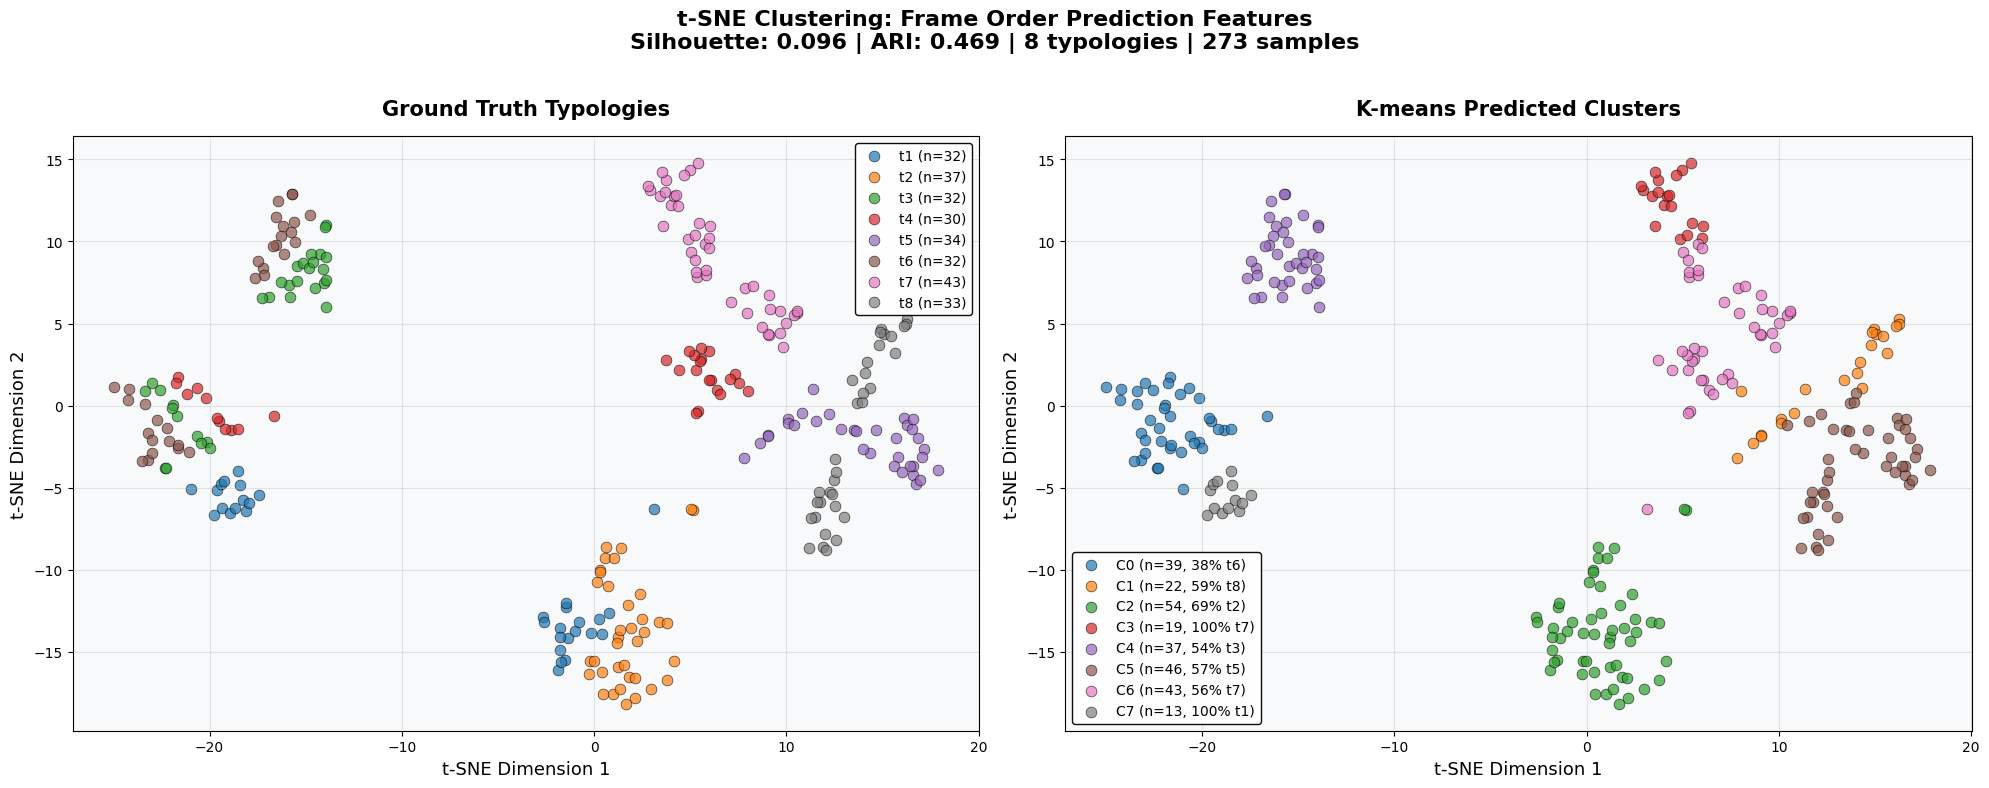


t-SNE plot saved to: ../models_temporal/output_temporal\tsne_clustering_temporal.png

VISUALIZATION GUIDE
LEFT PLOT (Ground Truth):
  - Each color = one typology (t1, t2, ...)
  - Points close together = similar temporal embeddings
  - If model learned well, same typology should cluster together

RIGHT PLOT (K-means Predictions):
  - Each color = one predicted cluster
  - Percentage shows cluster purity (% of dominant typology)
  - High purity + good separation = good temporal learning

Silhouette = 0.096:
  → Model struggled to learn typology distinctions.

ARI = 0.469:
  → Moderate agreement. Some clustering structure learned.


In [10]:
# Visualize t-SNE: Ground Truth vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Create color map
if num_clusters <= 10:
    colors = plt.cm.tab10(np.linspace(0, 1, 10))[:num_clusters]
else:
    colors = plt.cm.tab20(np.linspace(0, 1, 20))[:num_clusters]

# Create mapping from label to typology name
label_to_name = {}
for i, label in enumerate(labels):
    if label not in label_to_name:
        label_to_name[label] = typology_names_list[i]

# LEFT PLOT: Ground Truth Labels
ax = axes[0]
for i, label_idx in enumerate(unique_labels):
    mask = labels == label_idx
    typology_name = label_to_name[label_idx]
    count = np.sum(mask)
    ax.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=[colors[i]],
        label=f'{typology_name} (n={count})',
        alpha=0.7,
        s=60,
        edgecolors='black',
        linewidths=0.5,
    )

ax.set_xlabel('t-SNE Dimension 1', fontsize=13)
ax.set_ylabel('t-SNE Dimension 2', fontsize=13)
ax.set_title(
    'Ground Truth Typologies',
    fontsize=15,
    fontweight='bold',
    pad=15
)
ax.legend(loc='best', fontsize=10, framealpha=0.95, edgecolor='black')
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f8f9fa')

# RIGHT PLOT: Predicted Clusters (K-means)
ax = axes[1]
unique_pred_labels = np.unique(pred_labels)
for i, pred_label_idx in enumerate(unique_pred_labels):
    mask = pred_labels == pred_label_idx
    count = np.sum(mask)
    # Find which ground truth typology is most common in this cluster
    gt_labels_in_cluster = labels[mask]
    most_common_gt = np.bincount(gt_labels_in_cluster).argmax()
    most_common_name = label_to_name[most_common_gt]
    purity = np.sum(gt_labels_in_cluster == most_common_gt) / len(gt_labels_in_cluster) * 100
    
    ax.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=[colors[i % len(colors)]],
        label=f'C{pred_label_idx} (n={count}, {purity:.0f}% {most_common_name})',
        alpha=0.7,
        s=60,
        edgecolors='black',
        linewidths=0.5,
    )

ax.set_xlabel('t-SNE Dimension 1', fontsize=13)
ax.set_ylabel('t-SNE Dimension 2', fontsize=13)
ax.set_title(
    'K-means Predicted Clusters',
    fontsize=15,
    fontweight='bold',
    pad=15
)
ax.legend(loc='best', fontsize=10, framealpha=0.95, edgecolor='black')
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f8f9fa')

# Overall title with metrics
fig.suptitle(
    f't-SNE Clustering: Frame Order Prediction Features\n' + 
    f'Silhouette: {silhouette:.3f} | ARI: {ari:.3f} | {num_clusters} typologies | {len(embeddings)} samples',
    fontsize=16,
    fontweight='bold',
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(OUTPUT_DIR, 'tsne_clustering_temporal.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nt-SNE plot saved to: {os.path.join(OUTPUT_DIR, 'tsne_clustering_temporal.png')}")
print()
print("="*80)
print("VISUALIZATION GUIDE")
print("="*80)
print("LEFT PLOT (Ground Truth):")
print("  - Each color = one typology (t1, t2, ...)")
print("  - Points close together = similar temporal embeddings")
print("  - If model learned well, same typology should cluster together")
print()
print("RIGHT PLOT (K-means Predictions):")
print("  - Each color = one predicted cluster")
print("  - Percentage shows cluster purity (% of dominant typology)")
print("  - High purity + good separation = good temporal learning")
print()
print(f"Silhouette = {silhouette:.3f}:")
if silhouette > 0.3:
    print("  → Model learned excellent typology-distinguishing temporal features!")
elif silhouette > 0.1:
    print("  → Model learned some typology structure.")
else:
    print("  → Model struggled to learn typology distinctions.")
print()
print(f"ARI = {ari:.3f}:")
if ari > 0.5:
    print("  → Strong agreement! Predicted clusters match typologies well.")
elif ari > 0.3:
    print("  → Moderate agreement. Some clustering structure learned.")
else:
    print("  → Weak agreement. Clusters don't align with typologies.")
print("="*80)

## Summary

In [ ]:
print("="*80)
print("TRAINING SUMMARY")
print("="*80)
print()
print(f"Model: Frame Order Prediction (Temporal Learning)")
print(f"Epochs trained: {len(train_losses)}")
print(f"Best val loss: {best_val_loss:.4f}")
print(f"Final val accuracy: {val_accs[-1]:.3f}")
print()
print("Self-supervised task:")
print("  - Shuffle all 7 frames in the sequence")
print("  - Predict the original position (0-6) of each frame")
print("  - Forces model to learn temporal structure")
print()
print("Output files:")
print(f"  Best model: {os.path.join(CHECKPOINT_DIR, 'best_model.pt')}")
print(f"  Encoder: {os.path.join(OUTPUT_DIR, 'encoder_temporal_pretrained.pt')}")
print(f"  Training curves: {os.path.join(OUTPUT_DIR, 'training_curves.png')}")
print()
print("Next steps:")
print("  1. Fine-tune encoder on classification task")
print("  2. Compare with SimCLR and MAE approaches")
print("  3. Analyze which temporal features were learned")
print("="*80)